# Training Results & Evaluation Metrics
### Run this after all training notebooks complete — save outputs for viva

# Multimodal Deepfake Detection: Hold-Out Evaluation
This notebook evaluates the system on unseen hold-out videos to provide an accurate representation of real-world performance.

### Understanding the Metrics
* **Accuracy:** Out of all videos evaluated, how many did the model classify correctly?
* **AUC-ROC (Area Under Curve):** Measures the model's ability to separate real from fake. `1.0` is perfect, `0.5` is random guessing. This is the most reliable metric for model robustness.
* **Precision:** When the model flags a video as "FAKE", how often is it actually fake? High precision = very few innocent videos wrongly flagged.
* **Recall (Sensitivity):** Out of all actual fake videos, how many did the model successfully catch? High recall = very few deepfakes slipped through.
* **Specificity:** Out of all actual real videos, how many were correctly identified as real?

In [6]:
# CELL 1: SETUP & IMPORTS
!pip install torch torchvision scikit-learn matplotlib seaborn tqdm librosa -q

from google.colab import drive
drive.mount('/content/drive')

import os, json, numpy as np, torch, torch.nn as nn, cv2, collections
from torchvision import transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score,
    classification_report
)
import warnings; warnings.filterwarnings("ignore")
import urllib.request
import librosa

# --- PATHS ---
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/deepfake-project"
MODEL_DIR = os.path.join(BASE_DIR, "models")
TEST_VIDEOS_DIR = os.path.join(BASE_DIR, "data/test_videos")
RESULTS_DIR = os.path.join(BASE_DIR, "outputs/results")
WORK_DIR = "/tmp/test_eval_faces"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(WORK_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
print(f"Device: {DEVICE}")

# --- HELPER FUNCTIONS ---
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

if not os.path.exists("/tmp/deploy.prototxt"):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt", "/tmp/deploy.prototxt")
    urllib.request.urlretrieve("https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel", "/tmp/face_model.caffemodel")
face_net = cv2.dnn.readNetFromCaffe("/tmp/deploy.prototxt", "/tmp/face_model.caffemodel")

def detect_and_crop_face(img_bgr, size=IMG_SIZE):
    h, w = img_bgr.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(img_bgr,(300,300)),1.0,(300,300),(104.,177.,123.))
    face_net.setInput(blob); dets = face_net.forward()
    best_conf, best_box = 0.0, None
    for i in range(dets.shape[2]):
        conf = float(dets[0,0,i,2])
        if conf > best_conf:
            best_conf = conf
            box = dets[0,0,i,3:7] * np.array([w,h,w,h])
            best_box = box.astype(int)
    if best_conf < 0.5 or best_box is None: return None
    x1,y1,x2,y2 = best_box
    pw, ph = int((x2-x1)*0.20), int((y2-y1)*0.20)
    x1,y1 = max(0,x1-pw), max(0,y1-ph)
    x2,y2 = min(w,x2+pw), min(h,y2+ph)
    face = img_bgr[y1:y2, x1:x2]
    return cv2.resize(face,(size,size)) if face.size > 0 else None

def extract_faces_from_video(video_path, out_dir, video_id, max_frames=30):
    os.makedirs(out_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return []
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 1
    indices = np.linspace(0, total-1, min(max_frames, total), dtype=int)
    saved = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret: continue
        face = detect_and_crop_face(frame)
        if face is None: continue
        fp = os.path.join(out_dir, f"{video_id}_f{idx:05d}.jpg")
        cv2.imwrite(fp, face); saved.append(fp)
    cap.release()
    return saved

def extract_audio_from_video(video_path, out_wav):
    os.system(f'ffmpeg -y -i "{video_path}" -ar 16000 -ac 1 "{out_wav}" -loglevel quiet')
    return os.path.exists(out_wav)

def compute_mel_spec(wav_path, size=128):
    try:
        y, _ = librosa.load(wav_path, sr=16000, mono=True)
        mel = librosa.feature.melspectrogram(y=y, sr=16000, n_fft=1024, hop_length=512, n_mels=128)
        lm = librosa.power_to_db(mel, ref=np.max)
        lm = (lm-lm.min())/(lm.max()-lm.min()+1e-8)
        img = np.array(Image.fromarray((lm*255).astype(np.uint8)).resize((size,size)), dtype=np.float32)/255.0
        return img
    except: return None

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [7]:
# CELL 2: LOAD MODELS
class VisualCNN(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(1792,512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512,1))
    def forward(self, x):
        return self.classifier(self.pool(self.features(x)).flatten(1)).squeeze(1)

class AudioCRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(),nn.MaxPool2d(2))
        self.gru = nn.GRU(128*16,128,batch_first=True,bidirectional=True)
        self.fc = nn.Sequential(nn.Dropout(0.5),nn.Linear(256,64),nn.ReLU(),nn.Linear(64,1))
    def forward(self, x):
        f=self.cnn(x); B,C,H,W=f.shape
        f=f.permute(0,3,1,2).reshape(B,W,C*H); out,_=self.gru(f)
        return self.fc(out[:,-1,:]).squeeze(1)

class FreqCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1),nn.BatchNorm2d(256),nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),nn.Flatten(),
            nn.Dropout(0.5),nn.Linear(256,64),nn.ReLU(),nn.Linear(64,1))
    def forward(self, x): return self.net(x).squeeze(1)

def load_model(cls, path, device=DEVICE):
    m = cls().to(device)
    if os.path.exists(path):
        m.load_state_dict(torch.load(path, map_location=device))
        print(f"Loaded {os.path.basename(path)}")
    else:
        print(f"NOT FOUND: {os.path.basename(path)}")
    m.eval(); return m

print("Loading trained models...")
visual_model = load_model(VisualCNN, os.path.join(MODEL_DIR,"visual_cnn.pth"))
audio_model  = load_model(AudioCRNN, os.path.join(MODEL_DIR,"audio_crnn.pth"))
freq_model   = load_model(FreqCNN,   os.path.join(MODEL_DIR,"freq_model.pth"))

Loading trained models...
Loaded visual_cnn.pth
Loaded audio_crnn.pth
Loaded freq_model.pth


In [8]:
# CELL 3: SMART DATA LOADING (VIDEO REGISTRY)
print("Processing Test Videos into Registry...")

# Folders map to (Label, Has_Audio) based on your Drive structure
SPLITS = [
    ("fake", 1, False),
    ("real", 0, False),
    ("fake-with-audio", 1, True),
    ("real-with-audio", 0, True),
]

video_registry = {}

for split_name, label, has_audio in SPLITS:
    split_dir = os.path.join(TEST_VIDEOS_DIR, split_name)
    if not os.path.isdir(split_dir): continue

    videos = sorted(Path(split_dir).glob("*.mp4"))
    print(f"Processing {split_name}: {len(videos)} videos")

    for vp in tqdm(videos, leave=False):
        vid_id = f"{split_name}_{vp.stem}"
        out_sub = os.path.join(WORK_DIR, split_name)

        # Extract Frames
        faces = extract_faces_from_video(str(vp), out_sub, vid_id, max_frames=30)
        ffts = []

        # Compute FFTs
        for fp in faces:
            img = cv2.imread(fp)
            if img is not None:
                gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY).astype(np.float32)
                gray = cv2.resize(gray,(224,224))
                fmap = 20*np.log(np.abs(np.fft.fftshift(np.fft.fft2(gray)))+1)
                fmap = (fmap-fmap.min())/(fmap.max()-fmap.min()+1e-8)
                fft_save = fp.replace(".jpg","_fft.npy")
                np.save(fft_save, fmap.astype(np.float32))
                ffts.append(fft_save)

        # Compute Audio Spec
        spec_arr = None
        if has_audio:
            wav_path = os.path.join(WORK_DIR, vid_id + ".wav")
            if extract_audio_from_video(str(vp), wav_path):
                spec_arr = compute_mel_spec(wav_path)

        # Register the video
        if len(faces) > 0:
            video_registry[vid_id] = {
                'label': label,
                'has_audio': has_audio,
                'faces': faces,
                'ffts': ffts,
                'spec': spec_arr
            }

print(f"\nRegistry complete! Registered {len(video_registry)} videos for inference.")

Processing Test Videos into Registry...
Processing fake: 30 videos


Processing real: 30 videos


Processing fake-with-audio: 15 videos


Processing real-with-audio: 15 videos



Registry complete! Registered 90 videos for inference.


In [9]:
# CELL 4: INFERENCE & FUSION
print("Running Inference & Fusion...")

fused_probs = []
fused_labels = []

# For comparative metrics
vid_vis_probs = []
vid_frq_probs = []
vid_aud_probs = [] # Will only contain videos with audio
aud_labels_only = []

for vid_id, data in tqdm(video_registry.items()):
    # 1. Visual Inference (Average across all frames)
    vis_scores = []
    for fp in data['faces']:
        img = Image.open(fp).convert("RGB")
        t = val_tf(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            vis_scores.append(torch.sigmoid(visual_model(t)).item())
    p_vis = np.mean(vis_scores) if vis_scores else 0.5

    # 2. Frequency Inference (Average across all frames)
    frq_scores = []
    for fp in data['ffts']:
        fmap = np.load(fp).astype(np.float32)
        t = torch.tensor(fmap).unsqueeze(0).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            frq_scores.append(torch.sigmoid(freq_model(t)).item())
    p_frq = np.mean(frq_scores) if frq_scores else 0.5

    # 3. Audio Inference (If exists)
    p_aud = None
    if data['has_audio'] and data['spec'] is not None:
        t = torch.tensor(data['spec']).unsqueeze(0).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            p_aud = torch.sigmoid(audio_model(t)).item()
        vid_aud_probs.append(p_aud)
        aud_labels_only.append(data['label'])

    # 4. MULTIMODAL FUSION
    if p_aud is not None:
        # Fusion with audio
        p_fused = (0.45 * p_vis) + (0.35 * p_frq) + (0.20 * p_aud)
    else:
        # Fallback Fusion (Silent Videos)
        p_fused = (0.60 * p_vis) + (0.40 * p_frq)

    fused_probs.append(p_fused)
    fused_labels.append(data['label'])
    vid_vis_probs.append(p_vis)
    vid_frq_probs.append(p_frq)

def compute_metrics(probs, labels, name, threshold=0.5):
    if len(labels) == 0: return None
    preds = [1 if p>threshold else 0 for p in probs]
    acc = accuracy_score(labels, preds)
    auc = roc_auc_score(labels, probs) if len(set(labels))>1 else float('nan')
    cm = confusion_matrix(labels, preds)
    return {"name": name, "n_samples": len(labels), "accuracy": round(acc,4), "auc_roc": round(auc,4), "confusion_matrix": cm.tolist(), "probs": probs, "labels": labels, "preds": preds}

system_metrics = compute_metrics(fused_probs, fused_labels, "Fused System")
vis_metrics = compute_metrics(vid_vis_probs, fused_labels, "Visual CNN")
frq_metrics = compute_metrics(vid_frq_probs, fused_labels, "Freq CNN")
aud_metrics = compute_metrics(vid_aud_probs, aud_labels_only, "Audio CRNN")

print(f"\n--- FINAL VIDEO-LEVEL RESULTS ---")
print(f"Overall System Acc : {system_metrics['accuracy']*100:.2f}% | AUC: {system_metrics['auc_roc']:.4f}")
print(f"Visual Only Acc    : {vis_metrics['accuracy']*100:.2f}% | AUC: {vis_metrics['auc_roc']:.4f}")

Running Inference & Fusion...


100%|██████████| 90/90 [00:54<00:00,  1.65it/s]


--- FINAL VIDEO-LEVEL RESULTS ---
Overall System Acc : 72.22% | AUC: 0.8202
Visual Only Acc    : 76.67% | AUC: 0.9170


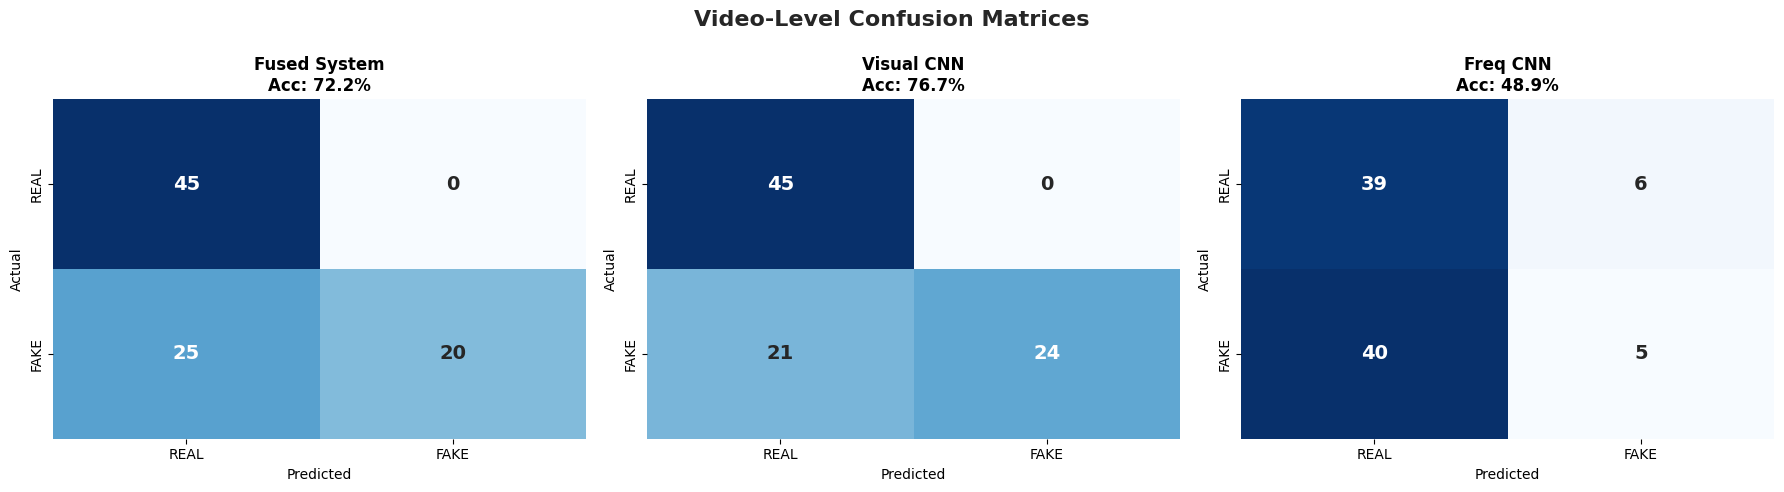

In [10]:
# CELL 5: CONFUSION MATRICES
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor="#FFFFFF")
sns.set_theme(style="white")

metrics_to_plot = [system_metrics, vis_metrics, frq_metrics]

for ax, m in zip(axes, metrics_to_plot):
    if m is None: continue
    cm_arr = np.array(m["confusion_matrix"])
    sns.heatmap(cm_arr, annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=["REAL", "FAKE"], yticklabels=["REAL", "FAKE"],
                annot_kws={"size":14, "weight":"bold"}, cbar=False)
    ax.set_title(f"{m['name']}\nAcc: {m['accuracy']*100:.1f}%", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Video-Level Confusion Matrices", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

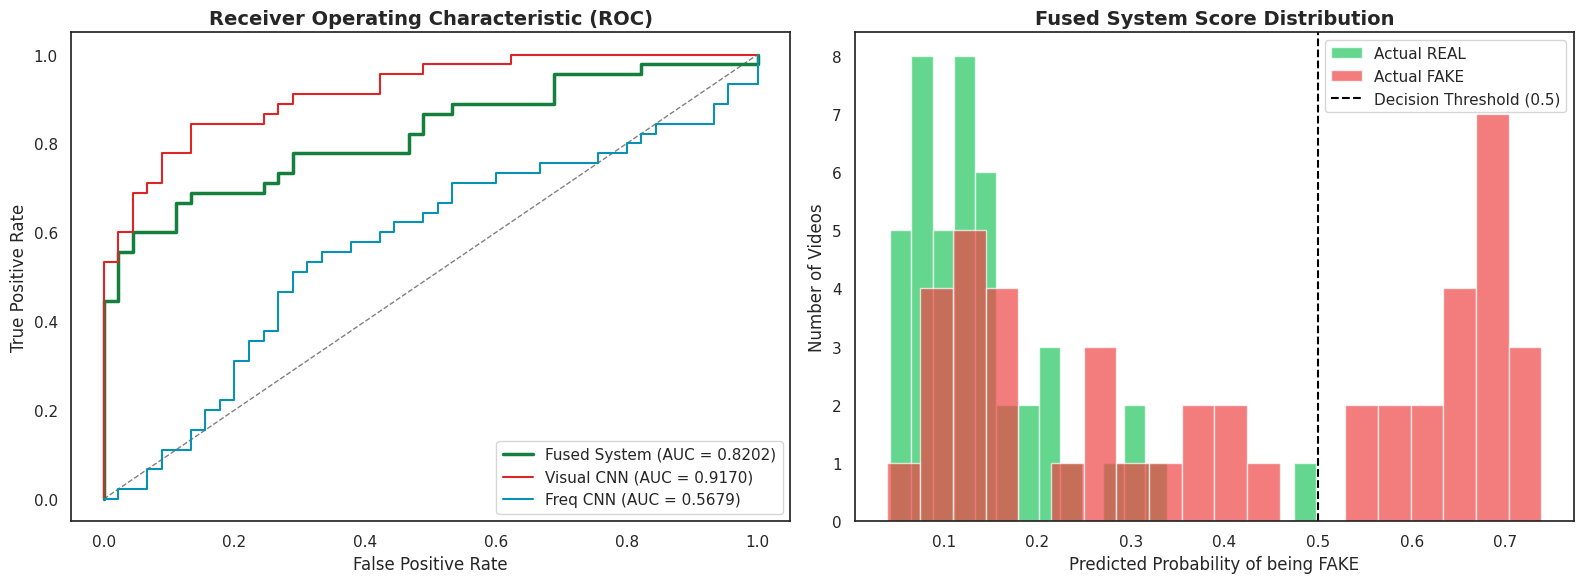

In [11]:
# CELL 6: ROC & SCORE DISTRIBUTIONS
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="#FFFFFF")
sns.set_theme(style="whitegrid")

# Plot 1: ROC Curves
axes[0].plot([0,1], [0,1], color="gray", lw=1, ls="--")
for m, color in zip([system_metrics, vis_metrics, frq_metrics], ["#15803D", "#DC2626", "#0891B2"]):
    if m is None or len(set(m['labels'])) < 2: continue
    fpr, tpr, _ = roc_curve(m["labels"], m["probs"])
    axes[0].plot(fpr, tpr, color=color, lw=2.5 if m['name']=="Fused System" else 1.5,
                 label=f"{m['name']} (AUC = {m['auc_roc']:.4f})")

axes[0].set_title("Receiver Operating Characteristic (ROC)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

# Plot 2: Fused System Score Distribution
real_p = [p for p, l in zip(system_metrics['probs'], system_metrics['labels']) if l == 0]
fake_p = [p for p, l in zip(system_metrics['probs'], system_metrics['labels']) if l == 1]

axes[1].hist(real_p, bins=20, color="#22C55E", alpha=0.7, label="Actual REAL")
axes[1].hist(fake_p, bins=20, color="#EF4444", alpha=0.7, label="Actual FAKE")
axes[1].axvline(0.5, color="black", ls="--", label="Decision Threshold (0.5)")

axes[1].set_title("Fused System Score Distribution", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Predicted Probability of being FAKE")
axes[1].set_ylabel("Number of Videos")
axes[1].legend()

plt.tight_layout()
plt.show()